In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [15]:
# Load dataset
df = pd.read_csv(
    "../data/raw/dontpatronizeme_pcl.tsv",
    sep="\t",
    skiprows=3,
    header=None
)
df.columns = ["par_id", "art_id", "keyword", "country", "text", "label"]
print(print(df.shape))
print(df.info())

(10469, 6)
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10469 entries, 0 to 10468
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   par_id   10469 non-null  int64 
 1   art_id   10469 non-null  object
 2   keyword  10469 non-null  object
 3   country  10469 non-null  object
 4   text     10468 non-null  object
 5   label    10469 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 490.9+ KB
None


In [16]:
df.head()

,par_id,art_id,keyword,country,text,label
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0
2,3,@@16584954,immigrant,ie,White House press secretary Sean Spicer said t...,0
3,4,@@7811231,disabled,nz,Council customers only signs would be displaye...,0
4,5,@@1494111,refugee,ca,""" Just like we received migrants fleeing El Sa...",0


In [10]:
df['keyword'].value_counts()


keyword
migrant          1089
in-need          1082
vulnerable       1080
homeless         1077
women            1070
refugee          1068
immigrant        1061
disabled         1028
hopeless         1005
poor-families     909
Name: count, dtype: int64

In [11]:
df['country'].value_counts()


country
za    549
my    546
ph    545
pk    545
us    543
au    541
gb    540
ke    539
ie    537
ng    537
sg    535
in    530
ca    530
gh    523
nz    518
bd    512
lk    504
jm    490
hk    490
tz    415
Name: count, dtype: int64

### As defined in the paper...
- 0,1 = No PCL
- 2,3,4 = PCL

In [39]:
df['binary_label'] = df['label'].apply(lambda x: 0 if x <= 1 else 1)

# Technique 1 - Class Distribution Analysis

In [40]:
# Count class distribution
class_counts = df['binary_label'].value_counts().sort_index()

class_distribution = pd.DataFrame({
    'Class': ['No PCL (0)', 'PCL (1)'],
    'Count': class_counts.values,
    'Percentage (%)': (class_counts.values / len(df)) * 100
})

class_distribution

,Class,Count,Percentage (%)
0,No PCL (0),9476,90.514853
1,PCL (1),993,9.485147


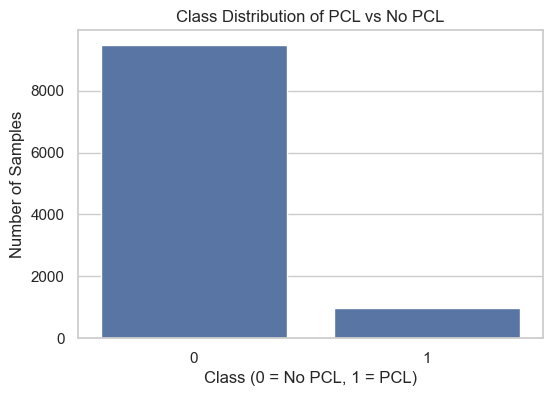

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(x='binary_label', data=df)

plt.title("Class Distribution of PCL vs No PCL")
plt.xlabel("Class (0 = No PCL, 1 = PCL)")
plt.ylabel("Number of Samples")

plt.savefig("../outputs/figures/class_distribution.png")

plt.show()

# Technique 2 - Token Distribution Analysis

In [26]:
df['token_length'] = df['text'].apply(lambda x: len(str(x).split()))

# Show first rows
df[['text', 'token_length']].head()

,text,token_length
0,"We 're living in times of absolute insanity , ...",123
1,"In Libya today , there are countless number of...",41
2,White House press secretary Sean Spicer said t...,27
3,Council customers only signs would be displaye...,30
4,""" Just like we received migrants fleeing El Sa...",53


In [27]:
# Summary statistics
token_stats = df['token_length'].describe()

token_stats

count    10469.000000
mean        48.422581
std         29.091174
min          1.000000
25%         30.000000
50%         42.000000
75%         60.000000
max        909.000000
Name: token_length, dtype: float64

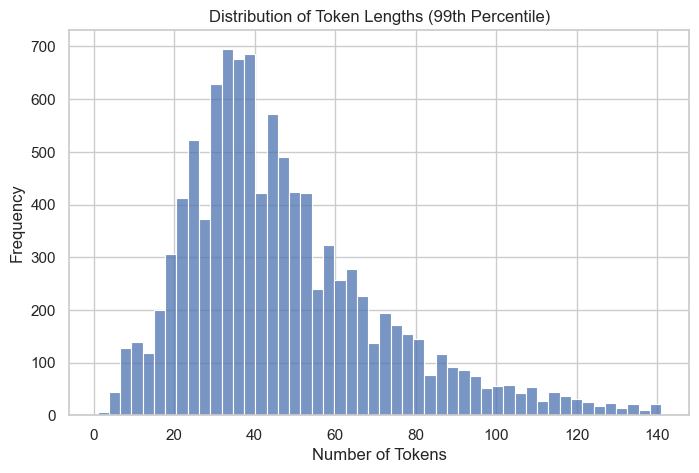

In [41]:
plt.figure(figsize=(8,5))

cutoff = df['token_length'].quantile(0.99) # 99th percentile cutoff
sns.histplot(df[df['token_length'] <= cutoff]['token_length'], bins=50)

plt.title("Distribution of Token Lengths (99th Percentile)")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")

plt.savefig("../outputs/figures/token_length_distribution.png")

plt.show()

In [42]:
df['token_length'].quantile([0.90, 0.95, 0.99])


0.90     83.00
0.95    102.00
0.99    141.32
Name: token_length, dtype: float64